In [ ]:
import glob
import os
import random
from collections import defaultdict
from itertools import combinations, permutations
from math import factorial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import stats
from scipy.signal import lfilter
from tqdm import tqdm

Parts of the analysis code (specifically the TDLM implementation) were adapted from previously published MATLAB code by Yunzhe Liu (original repository: [[link](https://github.com/YunzheLiu/TDLM)]). <br>
The code has been modified to fit the current dataset and experimental design.

# Methods

In [ ]:
def generate_permutations(sequence, n_permutation=1000, seed=None):
    """Generate shuffled sequences, excluding the target sequence and its reverse."""
    sequence = list(sequence)
    reversed_sequence = sequence[::-1]
    n_states = len(sequence)
    total_perms = factorial(n_states)

    all_perms = set(permutations(sequence))
    all_perms.discard(tuple(sequence))
    all_perms.discard(tuple(reversed_sequence))

    random.seed(seed)
    if total_perms - 2 <= n_permutation:
        return list(all_perms)

    return random.sample(list(all_perms), n_permutation)


In [ ]:
def build_transition_matrix(sequence, n_states):
    """Build a first-order transition matrix from an ordered state sequence."""
    TM = np.zeros((n_states, n_states), dtype=int)
    for i, state in enumerate(sequence):
        if i:
            previous_state = sequence[i - 1]
            TM[previous_state, state] = 1
    return TM
    
def compute_em_glm_matrix_form(probas, lag=1, taus=None, fit_intercept=False):
    """Estimate empirical transition weights from probability time courses."""
    n_trials, n_timepoints, n_states = probas.shape

    if taus is None:
        taus = []

    max_tau = max(taus) if taus else 0
    max_shift = lag + max_tau
    n_valid_time = n_timepoints - max_shift
    if n_valid_time <= 0:
        raise ValueError("Not enough timepoints after applying lag and max(tau)")

    X = probas[:, :n_valid_time, :].reshape(-1, n_states)  # shape: (samples, n_states)
    Y = probas[:, lag : lag + n_valid_time, :].reshape(-1, n_states)  # shape: (samples, n_states)

    # Control covariates
    control_list = []
    for tau in taus:
        Z_tau = probas[:, lag + tau : lag + tau + n_valid_time, :].reshape(-1, n_states)
        control_list.append(Z_tau)

    if control_list:
        Z = np.hstack(control_list)  # shape: (samples, n_states * len(taus))
        X_full = np.hstack([X, Z])
    else:
        X_full = X

    if fit_intercept:
        X_full = np.hstack([np.ones((X_full.shape[0], 1)), X_full])

    # GLM: Y = X_full @ B
    B = np.linalg.pinv(X_full) @ Y  # shape: (n_predictors, n_states)

    # Extract EM = B.T[:, :n_states]
    offset = 1 if fit_intercept else 0
    EM = B[offset : offset + n_states]

    return EM

def frobenius_inner_product(A, B):
    return np.sum(A * B)  # np.trace(np.dot(A.T,B))

def second_level_glm(EM, M_seq):
    n_states = EM.shape[0]
    
    M_auto = np.eye(n_states)
    M_const = np.ones((n_states, n_states)) / n_states

    M_rseq = M_seq.T
    
    X_model = np.vstack([M_seq.flatten(), M_rseq.flatten(), M_auto.flatten(), M_const.flatten()]).T
    y = EM.flatten()
    
    sequenceness = np.linalg.pinv(X_model) @ y
    
    return sequenceness[:2]

def compute_sequenceness_em(EM, TM, metric='ols'):
    beta_glm = second_level_glm(EM, TM)
    forbenius = [frobenius_inner_product(EM, M) for M in [TM, TM.T]]
    
    if metric.lower() == 'ols':
        return beta_glm
    elif metric.lower() in ('forbenius', 'frobenius'):
        return forbenius
    else:
        raise ValueError(f"Metric ({metric}) must be 'ols' or 'frobenius'.")


In [ ]:
def TDLM_main(probas, target_sequence, lag, shuffled_sequence=None, fit_intercept=False, taus=None, metric='ols'):
    """Run TDLM for one lag and optionally for shuffled control sequences."""
    EM = compute_em_glm_matrix_form(probas, lag, fit_intercept=fit_intercept, taus=taus)
    n_states = EM.shape[0]
    
    TM = build_transition_matrix(target_sequence, n_states=n_states) # [0, 1] forward
    obs = compute_sequenceness_em(EM, TM, metric=metric)
    if shuffled_sequence is not None:
        perms = [compute_sequenceness_em(EM, build_transition_matrix(seq, n_states=n_states), metric=metric) for seq in shuffled_sequence] 
        return [obs] + perms
    else:
        return [obs]

In [5]:
def replay_detection_tdlm(group_obs, group_perm, alpha=0.05):
    # group_obs: nSubject, nLags, nDirection (F, R)
    # group_perm: nSubect, nLags, nPermutations, nDirection (F, R)
    replay_res = dict(diff=dict(), total=dict())

    # Forward + Backwards
    perm_dist = group_perm.sum(axis=-1).mean(axis=0).max(axis=0)
    obs = group_obs.sum(axis=-1).mean(axis=0).max()
    
    p_total = np.mean(perm_dist >= obs) # p-value
    thresh_total = np.percentile(perm_dist, (1-alpha)*100)

    replay_res['total']=dict(p_value=p_total, threshold=thresh_total)

    # Forward - Backwards, two tailed
    perm_dist = np.abs(np.diff(group_perm, axis=-1).mean(axis=0)).max(axis=0).flatten()
    obs = np.abs(np.diff(group_obs,axis=-1).mean(axis=0)).max()
    
    p_diff = np.mean(perm_dist >= obs) # p-value
    thresh_diff = np.percentile(perm_dist, (1-alpha)*100)

    replay_res['diff']=dict(p_value=p_diff, threshold=thresh_diff)

    # Forward
    perm_dist = group_perm[...,0].mean(axis=0).max(axis=0)
    obs = group_obs.mean(axis=0).max(axis=0)[0]
    p_fwd = np.mean(perm_dist >= obs)
    thresh_fwd = np.percentile(perm_dist, (1-alpha)*100)
    replay_res['fwd']=dict(p_value=p_fwd, threshold=thresh_fwd)

    # Backwards
    perm_dist = group_perm[...,1].mean(axis=0).max(axis=0)
    obs = group_obs.mean(axis=0).max(axis=0)[1]
    p_rev = np.mean(perm_dist >= obs)
    thresh_rev = np.percentile(perm_dist, (1-alpha)*100)
    replay_res['rev']=dict(p_value=p_rev, threshold=thresh_rev)    
    
    return replay_res

In [6]:
def compute_tdlm_sequence_evidence(trial_probas, Tseq, lag):
    replay_score = np.full(trial_probas.shape[0], np.nan)
    X_orig = trial_probas.copy()
    X_proj = X_orig @ Tseq
    
    X_seq = X_orig[:-lag, :] * X_proj[lag:, :] 
    replay_score[lag:] = X_seq.mean(axis=-1)
    return  replay_score


def find_replay_onsets(data, fs=100, window_ms=100, percentile=95):
    from scipy.signal import lfilter
    
    threshold = np.nanpercentile(data, percentile)
    
    win_size = int((window_ms / 1000) * fs)
    
    is_low = (data < threshold).astype(float)
    
    b = np.ones(win_size)
    a = [1]
    rolling_low_count = lfilter(b, a, is_low, axis=-1) # sum of is_low from (t - win_size + 1) to t
    
    is_high = data >= threshold
    
    # To check if PREVIOUS window was low at time 't', 
    prev_low_was_full = np.zeros_like(rolling_low_count, dtype=bool)
    prev_low_was_full[:, 1:] = (rolling_low_count[:, :-1] == win_size)
    
    onsets_mask = is_high & prev_low_was_full
    
    trial_idxs, time_idxs = np.where(onsets_mask)
    onsets = list(zip(trial_idxs, time_idxs))
    
    # Compute intervals
    ms_per_sample = 1000 / fs 
    
    all_intervals = list()
    
    trial_map = defaultdict(list)
    for trial_idx, time_idx in onsets:
        trial_map[trial_idx].append(time_idx)
    
    
    for trial_idx, times in trial_map.items():
        if len(times) > 1:
            sorted_times = sorted(times)
            
            diffs_in_samples = np.diff(sorted_times)
            diffs_in_ms = diffs_in_samples * ms_per_sample
            all_intervals += diffs_in_ms.tolist()
    
    
    return trial_map, np.array(all_intervals), threshold

In [ ]:
def evaluate_candidate_sequence(group_probas, candidate_seq, lag_rng, shuffled_sequence=None, taus=None, fit_intercept=True, metric='ols'):
    """Evaluate one candidate sequence for every subject and requested lag."""
    tdlm = list()
    for probas in group_probas:
        results = Parallel(n_jobs=-1, require='sharedmem')(
        delayed(TDLM_main)(
            probas, candidate_seq, 
            lag=i, 
            shuffled_sequence = shuffled_sequence, # No permutations
            fit_intercept=fit_intercept,
            taus=taus, 
            # taus=[10,20,30,40,50],
            metric=metric) # 'ols' or 'frobenius'
        for i in lag_rng)
        
        results = np.array(results)
        tdlm.append(results)
    return np.array(tdlm)

def optimize_subsequence(group_probas, full_sequence, lag_rng, min_length=3, n_permutation=1000, seed=42, **kws):
    from itertools import combinations
    
    current_seq = tuple(full_sequence)
    
    optimization_history = {}

    while len(current_seq) > min_length:
        target_len = len(current_seq) - 1
        
        # Generate all combinations dropping exactly ONE item
        candidates = list(combinations(current_seq, target_len))
        
        best_candidate = None
        best_score = - np.inf
        
        for cand in candidates:
            tdlm = evaluate_candidate_sequence(group_probas, cand, lag_rng, shuffled_sequence=None, **kws) #nSubject, nLags, 1, (F|B)
            
            avg_tdlm = np.mean(tdlm[:,:,0,:], axis=0).sum(axis=-1)
            score = np.max(avg_tdlm)

            if score > best_score:
                best_candidate = cand
                best_score = score
            
        current_seq = best_candidate
        
        perm_candidates = generate_permutations(current_seq, n_permutation=n_permutation, seed=seed)
        tdlm = evaluate_candidate_sequence(group_probas, cand, lag_rng, shuffled_sequence=perm_candidates, **kws) #nSubject, nLags, nSeqs, (F|B)
        
        perm_dist = np.mean(tdlm[:,:,1:,:], axis=0).sum(axis=-1).max(axis=0)
        perm_thresholds = np.percentile(perm_dist, [95,99,100])
        
        peak_lag = np.mean(tdlm[:,:,0], axis=0).sum(axis=-1).argmax(axis=0)
        
        optimization_history[target_len] = {'sequence': current_seq, 'tdlm': tdlm[:,:,0,:], 'peak_lag':peak_lag, 'thresholds':perm_thresholds}
    return optimization_history



# Configuration and Main Workflow



In [9]:
nstates = 8
bin_width = 10
n_permutation = 1000
lag_rng = range(1,101)

sequence = [0, 1, 2, 3, 4, 5, 6, 7]
perm_seq = generate_permutations(np.arange(nstates), n_permutation=n_permutation, seed=42)

In [ ]:

# Data configuration. Defaults preserve the original analysis environment.
base_path = Path(r"E:\sEEG\Exp1")
event_name = "Rest"
probas_subdir = Path("TDLM") / "Benchmark" / event_name

## TDLM sequenceness

In [ ]:
tdlm = defaultdict(list)
for subject_id in tqdm(os.listdir(base_path)):
    subject_path = base_path / subject_id / "Re"
    
    probas_path = subject_path / probas_subdir 
    files = glob.glob(str(probas_path / f"{subject_id}_Session*_{event_name}_probas.npz"))
    
    if len(files) == 0:
        continue
    
    # assert len(files) == 1
    # probas = np.load(files[0], allow_pickle=True)['data'] # sampling rate = 100 Hz
    # probas = np.transpose(probas, (1, 2, 0)) # ntrials, ntimes, nclasses

    probas = list()
    for fn in files:
        prob = np.load(fn, allow_pickle=True)['data'] # sampling rate = 100 Hz
        probas.append(prob)
        del prob
    probas = np.concatenate(probas, axis=0)
    
    results = Parallel(n_jobs=-1, require='sharedmem')(
    delayed(TDLM_main)(
        probas, sequence, 
        lag=i, 
        shuffled_sequence = perm_seq, 
        fit_intercept=True,
        taus=None, 
        # taus=[10,20,30,40,50],
        metric='ols') # 'ols' or 'frobenius'
    for i in lag_rng)
    results = np.array(results) # (nLags, nSeqs: [obs] + perm_seq, [Forward | Backward])
    
    
    tdlm['Obs'].append(results[:, 0])
    tdlm['Perms'].append(results[:, 1:])
    del results


100%|██████████| 18/18 [04:36<00:00, 15.35s/it]


In [10]:
group_obs = np.array(tdlm['Obs'])
group_perm = np.array(tdlm['Perms'])

replay_res = replay_detection_tdlm(group_obs, group_perm, alpha=0.05)
peak_lag = np.mean(group_obs.sum(axis=-1), axis=0).argmax(axis=0)

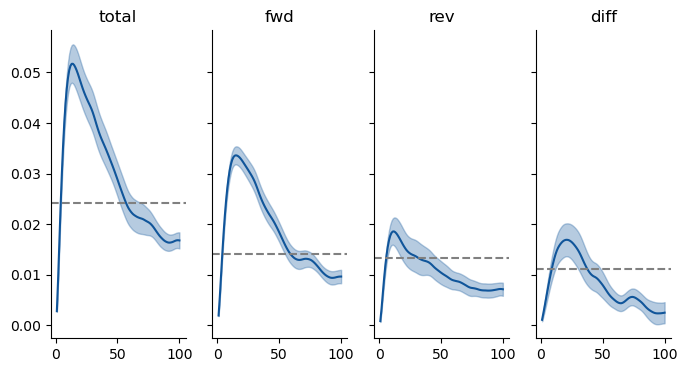

In [11]:
color_dict = {
    "Encoding": "#eebc42",
    # "Delay": "#a8b2b9",
    "Delay":"#5F9EA0",
    "TOJ": "#db4c77",
    "Rest": "#10559a"
}

fig, axes = plt.subplots(1,4, sharex=True, sharey=True, figsize=(8,4))
for ax, metric in zip(axes, ['total', 'fwd', 'rev','diff']):
    if metric == 'diff':
        obs = group_obs[...,0] - group_obs[...,1]
    elif metric == 'total':
        obs = group_obs[...,0] + group_obs[...,1]
    elif metric == 'fwd':
        obs = group_obs[...,0]
    else:
        obs = group_obs[...,1]
        
    _u = np.mean(obs, axis=0)
    _err = stats.sem(obs, axis=0)
    ax.plot(lag_rng, _u, label=metric, color=color_dict[event_name])
    ax.fill_between(lag_rng, _u - _err, _u + _err, alpha=.3, color=color_dict[event_name])
    ax.axhline(replay_res.get(metric).get('threshold'), color='gray', ls='dashed')
    ax.set_title(metric)
    sns.despine(ax=ax)

In [ ]:
# paired differences (condition-wise)
# vals = np.array(Cond_sum['Rev']) - np.array(Cond_sum['Nat'])
# t_obsarray, clusters, cluster_pv, _ = mne.stats.permutation_cluster_1samp_test(
    #     vals,
    #     tail=0,
    #     n_permutations='all',
    #     verbose='ERROR',
    #     n_jobs=-1
    # )

# behavioral correlation (trial-wise)
# results = Parallel(n_jobs=-1, require='sharedmem')(
# delayed(TDLM_main)(
#     trial_probas[np.newaxis,:,:], sequence,
#     lag=peak_lag, 
#     fit_intercept=True,
#     taus=None, 
#     metric='ols') 
# for trial_probas in probas)
# results = np.array(results)
# obs = results[:,0] # (nTrials, [F | B])

## TDLM evidence

<Axes: ylabel='Count'>

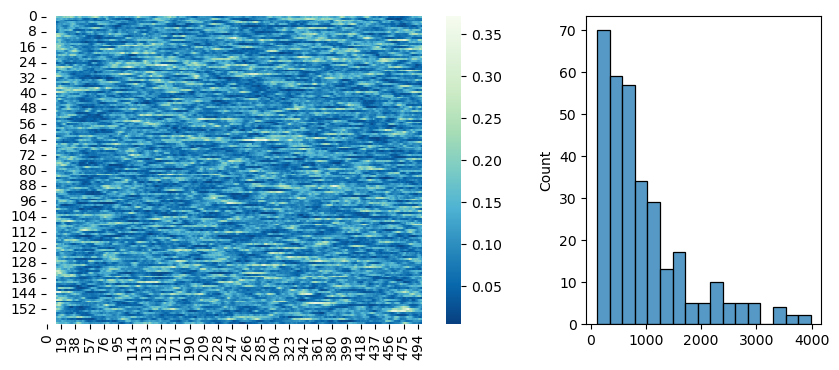

In [12]:
Tf =  build_transition_matrix(sequence, n_states=nstates) # [0, 1] forward

trial_evidence = [compute_tdlm_sequence_evidence(trial, Tf, peak_lag) for trial in probas] #examplar session
_, intervals, threshold = find_replay_onsets(trial_evidence)

fig, axes = plt.subplots(1, 2, figsize=(10,4), width_ratios=[2,1])
sns.heatmap(trial_evidence, cmap='GnBu_r', ax=axes[0])
sns.histplot(intervals, ax=axes[1])

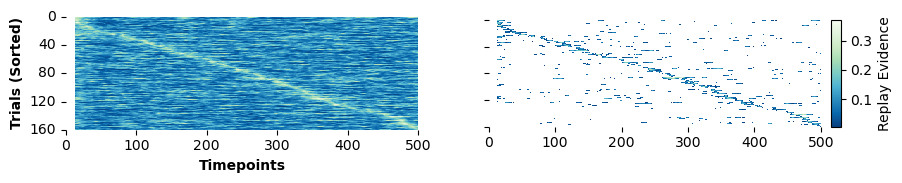

In [13]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

peak_times = np.array(trial_evidence)[:,peak_lag:].argmax(axis=1)
sort_indices = np.argsort(peak_times)
sorted_map =  np.array(trial_evidence)[sort_indices]

fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=True, sharex=True) # Adjust figsize as needed for your screen
ax = axes[0]
sns.heatmap(sorted_map, cmap='GnBu_r', square=True, cbar=False, ax=ax)

ax.set_xlabel("Timepoints", fontweight='bold')
ax.set_ylabel("Trials (Sorted)", fontweight='bold')
ax.set_xticks([0,100,200,300,400,500], [0,100,200,300,400,500], rotation=0)

ax = axes[1]
sns.heatmap(sorted_map, mask = sorted_map <= threshold, cmap='GnBu_r', square=True, cbar=False)

divider = make_axes_locatable(ax)
cbar_ax = divider.append_axes("right", size="3%", pad=0.1) # size is width, pad is distance
cbar = fig.colorbar(axes[0].collections[0], cax=cbar_ax)
cbar.set_label("Replay Evidence", fontsize=10)

ax.set_yticks([0, 40,80,120,160], [0, 40,80,120,160])
ax.set_xticks([0,100,200,300,400,500], [0,100,200,300,400,500], rotation=0)
plt.show()

## Sub-sequence

In [ ]:
subject_probas = list()
for subject_id in os.listdir(base_path):
    subject_path = base_path / subject_id / "Re"
    
    probas_path = subject_path / probas_subdir 
    files = glob.glob(str(probas_path / f"{subject_id}_Session*_{event_name}_probas.npz"))
    
    if len(files) == 0:
        continue
    
    # assert len(files) == 1
    # probas = np.load(files[0], allow_pickle=True)['data'] # sampling rate = 100 Hz
    # probas = np.transpose(probas, (1, 2, 0)) # ntrials, ntimes, nclasses

    probas = list()
    for fn in files:
        prob = np.load(fn, allow_pickle=True)['data'] # sampling rate = 100 Hz
        probas.append(prob)
        del prob
    probas = np.concatenate(probas, axis=0)
    
    subject_probas.append(probas)
    del probas

In [42]:
subsequence_hist = optimize_subsequence(subject_probas, sequence, 
                                        lag_rng, 
                                        min_length=3, 
                                        taus=None,
                                        fit_intercept=True,
                                        n_permutation=1000,
                                        metric='ols')

In [45]:
tdlm_matrix = list()
for seq_len, res in subsequence_hist.items():
    res = res.get('tdlm')
    tdlm_matrix.append(res.mean(axis=0).sum(axis=-1))
tdlm_matrix = np.array(tdlm_matrix)

<Axes: >

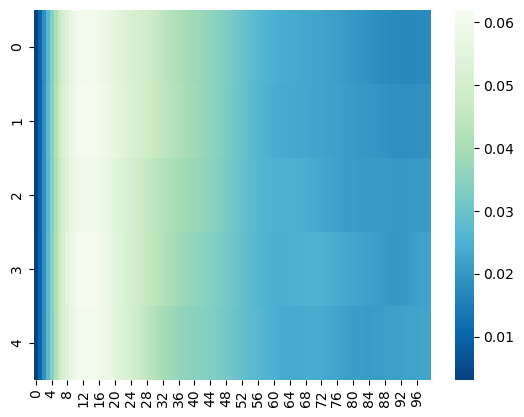

In [48]:
sns.heatmap(tdlm_matrix, cmap='GnBu_r')